## Experiment No: 4
## Experiment Title: Titanic Dataset Analysis

**Name:** Himanshu Jadhav  
**Roll Number:** SE-33


### 📌 Problem Statement

- Load the Titanic dataset.
- Handle missing values appropriately.
- Analyze survival rates based on gender, passenger class, and age.
- Create visualizations to support the analysis.

> **Dataset:** https://www.kaggle.com/datasets/yasserh/titanic-dataset


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset

df = pd.read_csv("Titanic-Dataset.csv")
print(df.head())
print("Shape : ", df.shape)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Sh

In [3]:
# Checking and Handling the Missing Values 

print("Missing Values Before: ")
print(df.isnull().sum())

Missing Values Before: 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
# Filling the missing Values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Dropping the Cabin column due to too many Nulls
df.drop(columns=['Cabin'], inplace=True, errors='ignore')

print("\nMissing Values After: ")
print(df.isnull().sum())


Missing Values After: 
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [5]:
# Survivsl Analysis By Gender

survival_gender = df.groupby('Sex')['Survived'].mean()
print("Survival Rates By Gender: ")
print(survival_gender)

Survival Rates By Gender: 
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


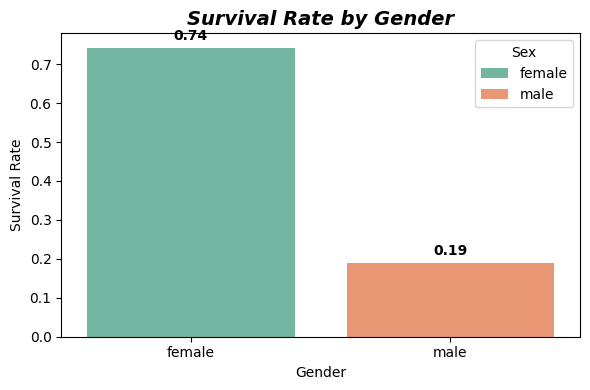

In [6]:
# Survivsl Analysis By Gender Plot

survival_rate = df.groupby('Sex')['Survived'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=survival_rate, x='Sex', y='Survived', hue='Sex', palette='Set2', legend=True)
plt.title('Survival Rate by Gender', fontsize=14, fontweight='bold', fontstyle='oblique')
plt.ylabel('Survival Rate')
plt.xlabel('Gender')

for index, row in survival_rate.iterrows():
    plt.text(index, row.Survived + 0.02, f"{row.Survived:.2f}", 
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
# Survival Analysis By Passenger Class

survival_class = df.groupby('Pclass')['Survived'].mean()
print("Survival Rate by Class: ")
print(survival_class)


Survival Rate by Class: 
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


Survival Rate by Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


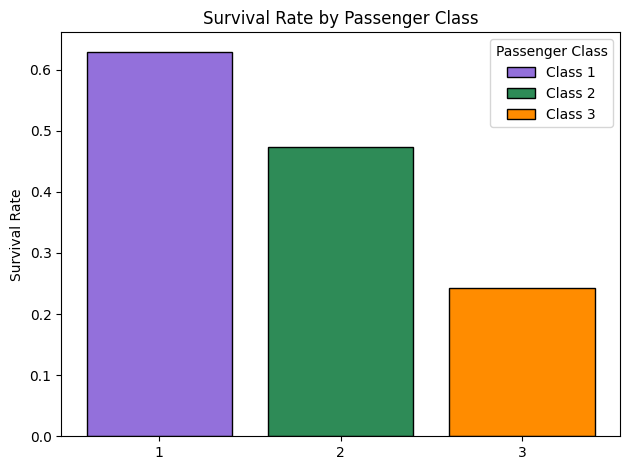

In [8]:

survival_class = df.groupby('Pclass')['Survived'].mean()
print("Survival Rate by Class:")
print(survival_class)

colors = ['mediumpurple', 'seagreen', 'darkorange']

for i, (cls, rate) in enumerate(survival_class.items()):
    plt.bar(cls, rate, color=colors[i], edgecolor='black', label=f'Class {cls}')

plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(survival_class.index, rotation=0)
plt.legend(title='Passenger Class')
plt.tight_layout()
plt.show()


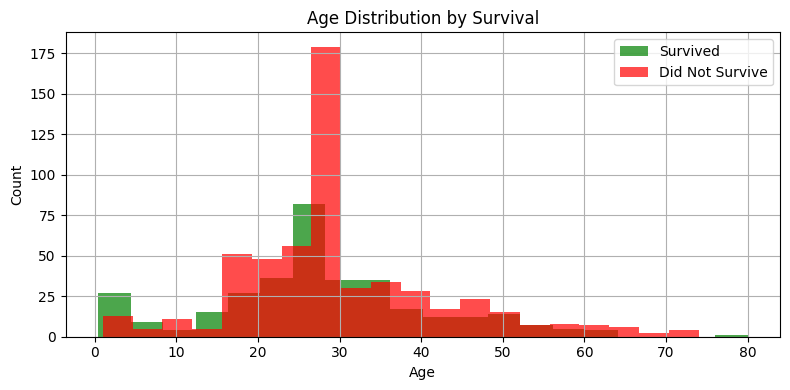

In [9]:
# Age Distribution By Survival 

plt.figure(figsize=(8, 4))
df[df['Survived'] == 1]['Age'].hist(bins=20, alpha=0.7, label='Survived', color='green')
df[df['Survived'] == 0]['Age'].hist(bins=20, alpha=0.7, label='Did Not Survive', color='red')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()



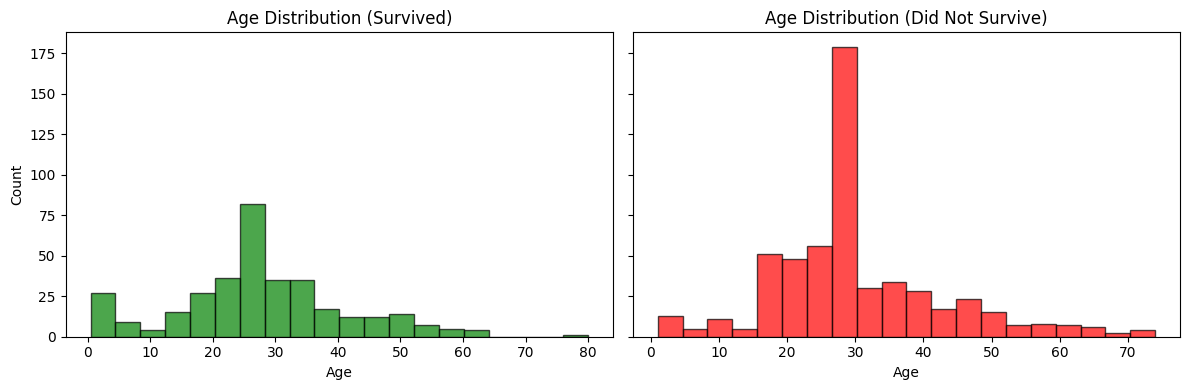

In [10]:
# Sub Plot 

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# Survived
axes[0].hist(df[df['Survived'] == 1]['Age'], bins=20, alpha=0.7, color="green", edgecolor="black")
axes[0].set_title('Age Distribution (Survived)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Did Not Survive
axes[1].hist(df[df['Survived'] == 0]['Age'], bins=20, alpha=0.7, color="red", edgecolor="black")
axes[1].set_title('Age Distribution (Did Not Survive)')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()